<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


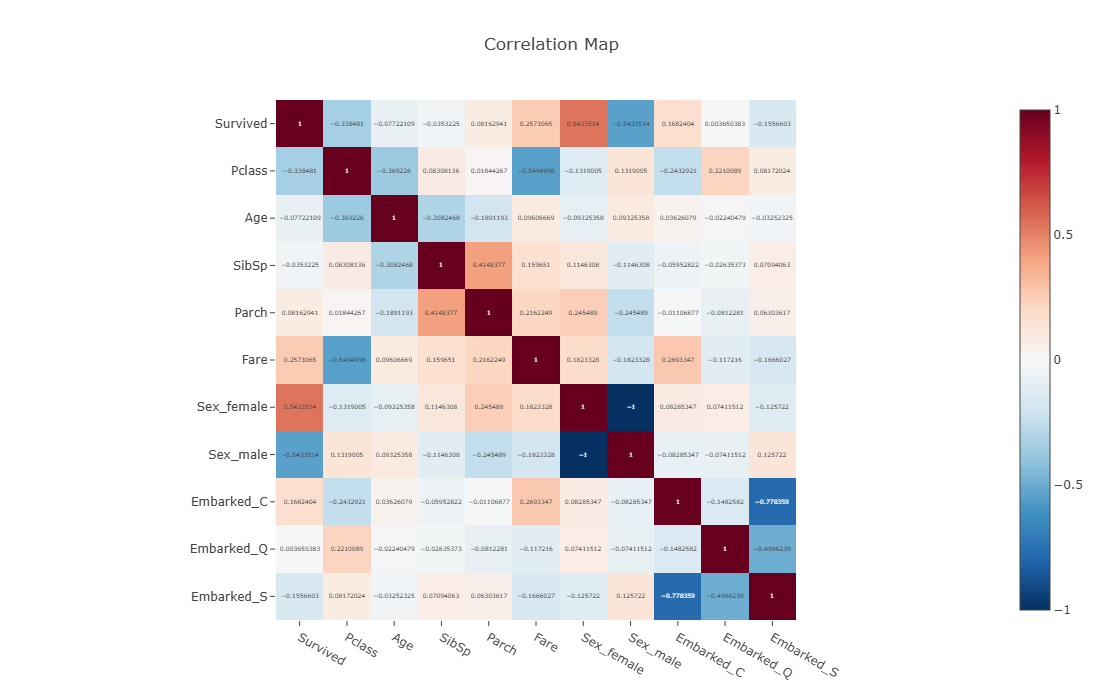

Unique values in categorical columns
Sex:['male' 'female']
Embarked:['S' 'C' 'Q' nan]


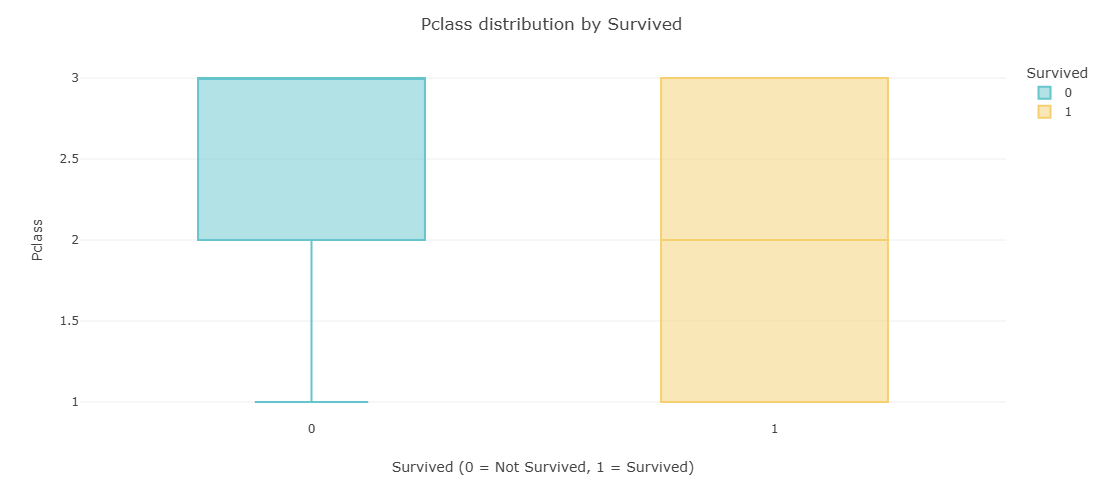

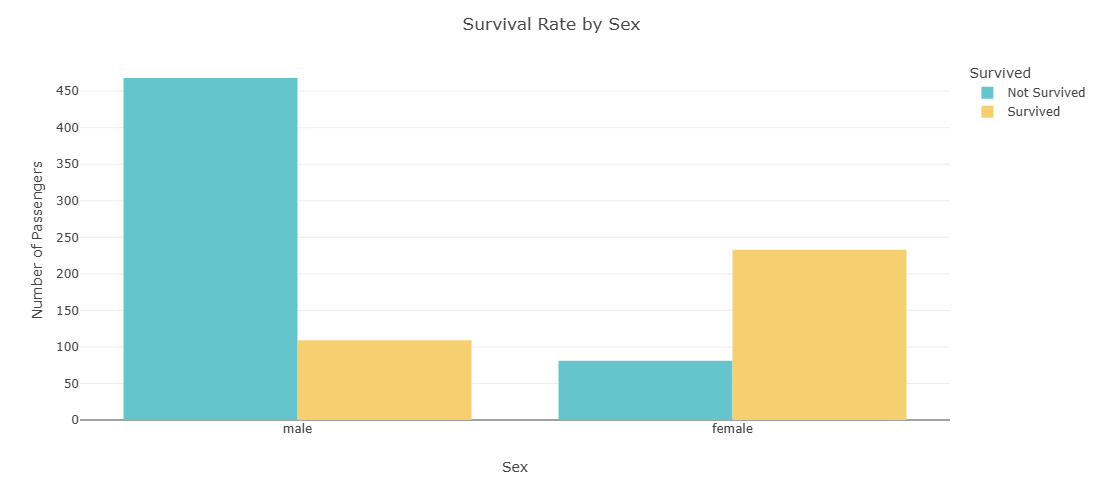

29.44047619047619
13.523898136661371


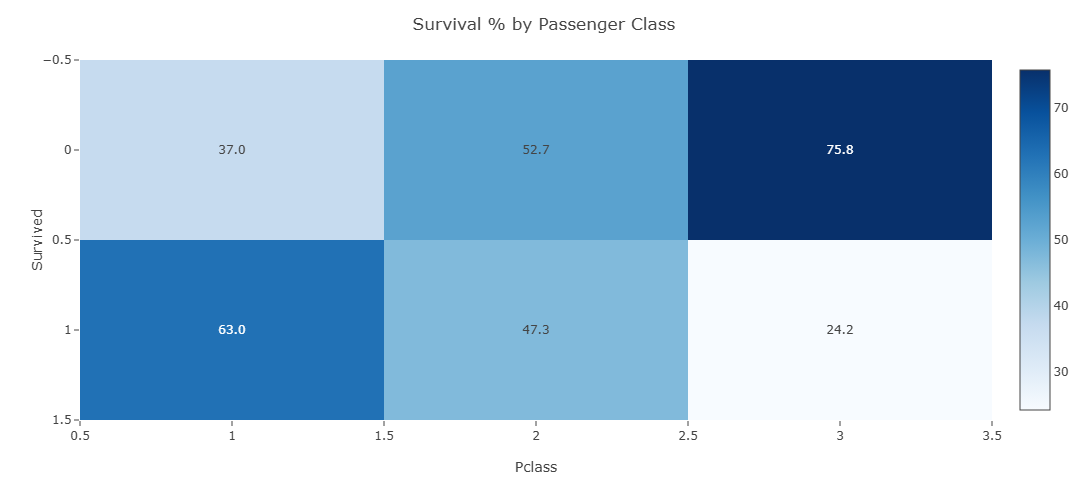

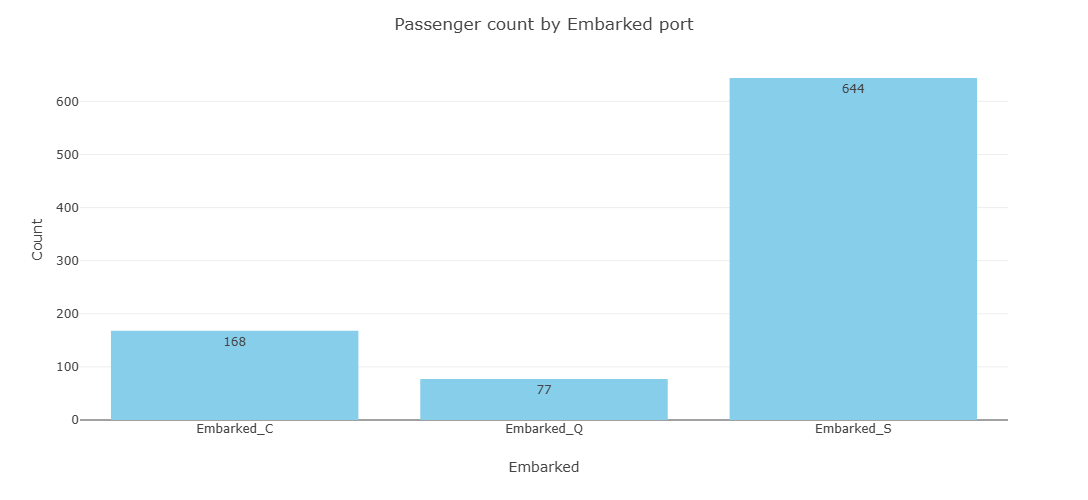

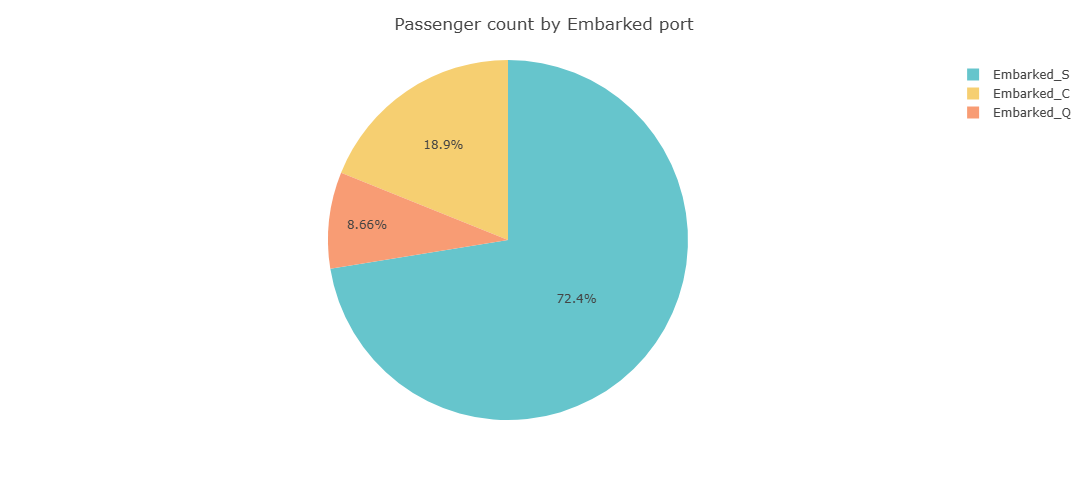

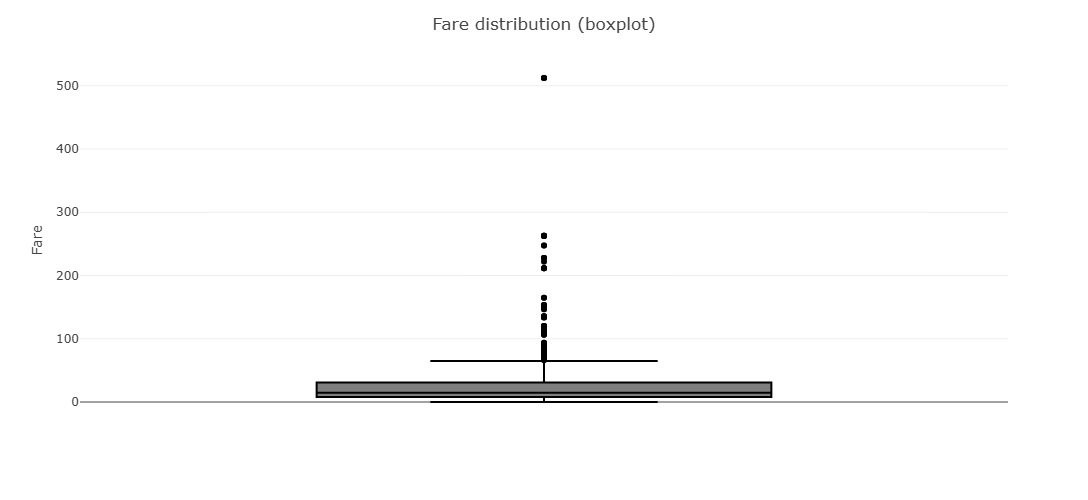

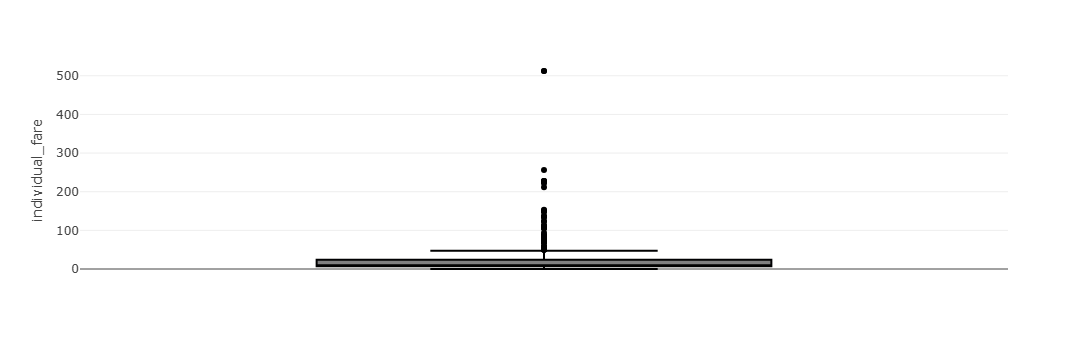

Pclass             0
Age                0
Fare               0
Sex_female         0
Sex_male           0
Embarked_C         0
Embarked_Q         0
Embarked_S         0
Family size        0
individual_fare    0
dtype: int64
     Pclass       Age      Fare  Sex_female  Sex_male  Embarked_C  Embarked_Q  \
0         3  34.50000    7.8292       False      True       False        True   
1         3  47.00000    7.0000        True     False       False       False   
2         2  62.00000    9.6875       False      True       False        True   
3         3  27.00000    8.6625       False      True       False       False   
4         3  22.00000   12.2875        True     False       False       False   
..      ...       ...       ...         ...       ...         ...         ...   
413       3  30.27259    8.0500       False      True       False       False   
414       1  39.00000  108.9000        True     False        True       False   
415       3  38.50000    7.2500       False     

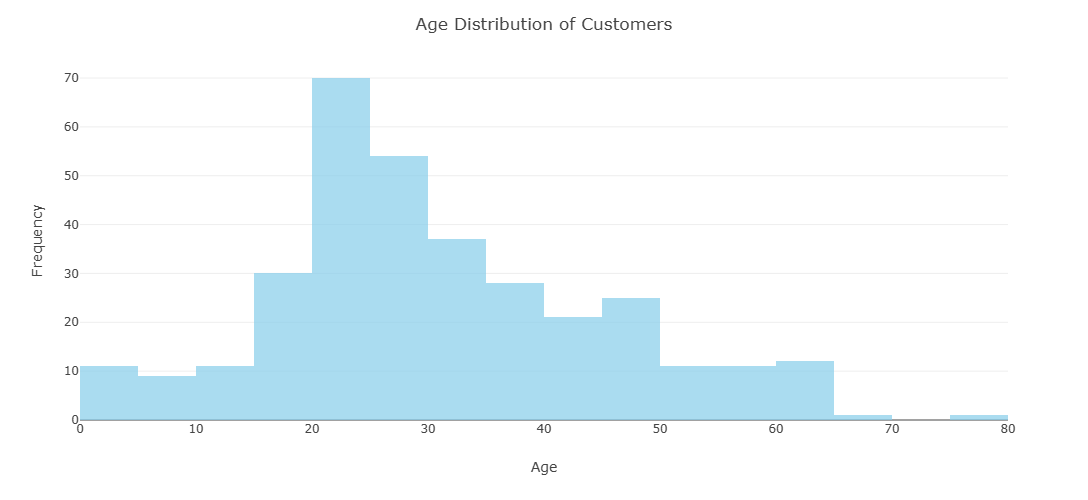

     Pclass       Age  SibSp  Parch      Fare  Sex_female  Sex_male  \
0         3  34.50000      0      0    7.8292       False      True   
1         3  47.00000      1      0    7.0000        True     False   
2         2  62.00000      0      0    9.6875       False      True   
3         3  27.00000      0      0    8.6625       False      True   
4         3  22.00000      1      1   12.2875        True     False   
..      ...       ...    ...    ...       ...         ...       ...   
413       3  30.27259      0      0    8.0500       False      True   
414       1  39.00000      0      0  108.9000        True     False   
415       3  38.50000      0      0    7.2500       False      True   
416       3  30.27259      0      0    8.0500       False      True   
417       3  30.27259      1      1   22.3583       False      True   

     Embarked_C  Embarked_Q  Embarked_S  Family size Family_type  
0         False        True       False            1       alone  
1         Fal

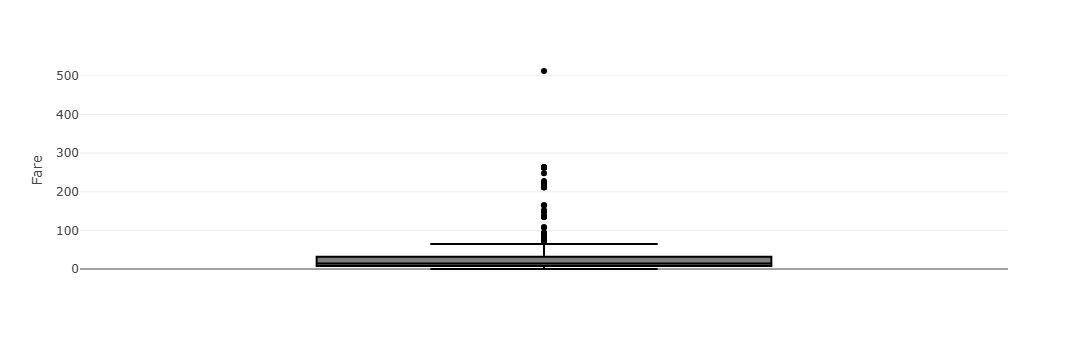

     Pclass       Age  SibSp  Parch      Fare  Sex_female  Sex_male  \
0       3.0  34.50000      0      0 -0.490783       False      True   
1       3.0  47.00000      1      0 -0.507479        True     False   
2       2.0  62.00000      0      0 -0.453367       False      True   
3       3.0  27.00000      0      0 -0.474005       False      True   
4       3.0  22.00000      1      1 -0.401017        True     False   
..      ...       ...    ...    ...       ...         ...       ...   
413     3.0  30.27259      0      0 -0.486337       False      True   
414     1.0  39.00000      0      0  1.544246        True     False   
415     3.0  38.50000      0      0 -0.502445       False      True   
416     3.0  30.27259      0      0 -0.486337       False      True   
417     3.0  30.27259      1      1 -0.198244       False      True   

     Embarked_C  Embarked_Q  Embarked_S  Family size Family_type  
0         False        True       False          1.0       alone  
1         Fal

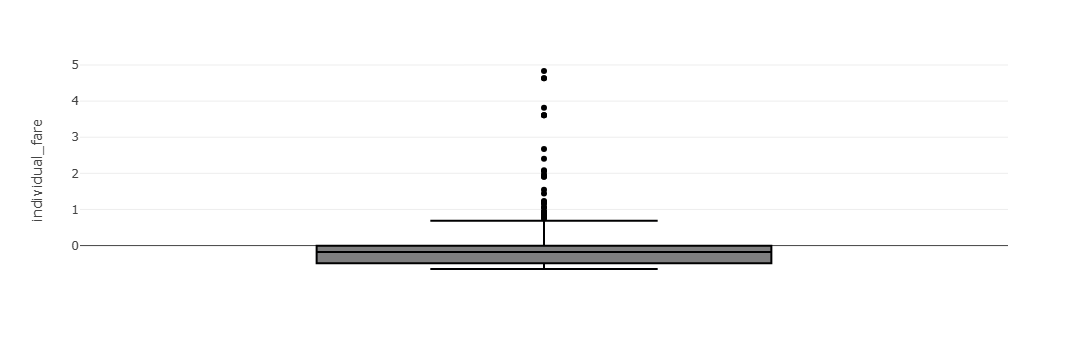

[0 0 0 0 0 0 0 0 0 0]
Model Evaluation Metrics:
Accuracy  : 0.7821
Precision : 0.7703
Recall    : 0.7215
F1-score  : 0.7451
ROC-AUC   : 0.8219
ROC curve saved as roc_curve.png


In [12]:
import pandas as pd

df = pd.read_csv('Titanic_train.csv')
df.info()
df.describe() 

df.head()

df.isnull().sum()

df.describe(include = object)

df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
df

df_encoded = pd.get_dummies(df)
df_encoded

correlation_matrix = df_encoded.corr()
correlation_matrix

import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

fig = px.imshow(correlation_matrix,text_auto=True,color_continuous_scale="RdBu_r",title="Correlation Map")
fig.update_layout(width=900,height=700)
fig.show()

df_encoded.isnull().sum()

mean_age = df['Age'].mean()
mean_age

df_encoded['Age'] = df_encoded['Age'].fillna(df_encoded['Age'].mean())
df_encoded['Age']

df_encoded['Age'].isnull().sum()

print('Unique values in categorical columns')
for col in ['Sex','Embarked']:
    print(f"{col}:{df[col].unique()}")

numerical_features = ['Pclass','Sex','Age','SibSp','Parch','Fare']
df[numerical_features].describe()

fig = px.box(df,x="Survived",y="Pclass",color="Survived", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Pclass distribution by Survived",xaxis_title="Survived (0 = Not Survived, 1 = Survived)",yaxis_title="Pclass",width=1000,height=500)
fig.show()

fig = px.histogram(df,x="Sex",color="Survived",  barmode="group",  color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Survival Rate by Sex",xaxis_title="Sex",yaxis_title="Number of Passengers",legend_title_text="Survived",width=1000,height=500)
fig.for_each_trace(lambda t: t.update(name="Not Survived" if t.name == "0" else "Survived"))
fig.show()

#box plot for age vs churn
fig = px.box(df,x="Survived",y="Age",color="Survived")
fig.update_layout(title="Age distribution by Survival status",xaxis_title="Survival (0 = Not Survived, 1 = Survived)",yaxis_title="Age",width=1000,height=500)

lower_outliers = df['Age'].quantile(0.05)
higher_outliers = df['Age'].quantile(0.95)
df['Age'] = np.where(df['Age'] < lower_outliers, lower_outliers,
             np.where(df['Age'] > higher_outliers, higher_outliers, df['Age']))

fig = px.box(df,x="Survived",y="Age",color="Survived", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Age distribution by Survival status",xaxis_title="Survival (0 = Not Survived, 1 = Survived)",yaxis_title="Age",width=1000,height=500)

mean_age = df['Age'].mean()
std_age = df['Age'].std()
print(mean_age)
print(std_age)

z_threshold = 3
upper_limit = mean_age + z_threshold * std_age
lower_limit = mean_age - z_threshold * std_age
for i in range(len(df)):
    if df.loc[i, 'Age'] < lower_limit:
        df.loc[i, 'Age'] = lower_limit
    elif df.loc[i, 'Age'] > upper_limit:
        df.loc[i, 'Age'] = upper_limit
fig = px.box(df,x="Survived",y="Age",color="Survived",color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Age distribution by Survival status",xaxis_title="Survival (0 = Not Survived, 1 = Survived)",yaxis_title="Age",width=1000,height=500)

crosstab = pd.crosstab(df['Survived'], df['Pclass'], normalize='columns') * 100

# Plot as heatmap
fig = px.imshow(crosstab,text_auto=".1f", color_continuous_scale="Blues", aspect="auto")
fig.update_layout(title="Survival % by Passenger Class",xaxis_title="Pclass",yaxis_title="Survived",width=800,height=500)
fig.show()

df_encoded['Family size'] = df['SibSp'] + df['Parch'] + 1
df_encoded['Family size'].value_counts()
df_encoded.describe()

def transform_family_size(num):
    if num == 1:
        return 'alone'
    elif num >1 and num <5:
        return 'small'
    else:
        return 'large'

import pandas as pd
df_encoded['Family_type'] = df_encoded['Family size'].apply(transform_family_size)
df_encoded

import pandas as pd
counts = df_encoded[['Embarked_C', 'Embarked_Q', 'Embarked_S']].sum()

fig = px.bar(counts,x=counts.index,y=counts.values,text=counts.values,color_discrete_sequence=["skyblue"])
fig.update_layout(title="Passenger count by Embarked port",xaxis_title="Embarked",yaxis_title="Count",width=800,height=500)
fig.show()

fig = px.pie(names=counts.index,values=counts.values,color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Passenger count by Embarked port",width=800,height=500)
fig.show()

fig = px.box(df_encoded, y="Fare", points="outliers") 
fig.update_layout(title="Fare distribution (boxplot)",yaxis_title="Fare",width=800,height=500)
fig.show()
df_encoded['individual_fare'] = df_encoded['Fare']/(df_encoded['SibSp'] + df_encoded['Parch'] + 1)
df_encoded

fig = px.box(df_encoded, y="individual_fare", points="outliers")
fig.show()

from scipy import stats
import numpy as np

z_scores = stats.zscore(df_encoded['individual_fare'])
mean_fare = df_encoded['individual_fare'].mean()

outliers = (np.abs(z_scores) > 3)
df_encoded.loc[outliers, 'individual_fare'] = mean_fare
df_encoded

x = df_encoded.drop(['SibSp','Parch','Survived','Family_type'],axis=1)
y=df_encoded['Survived']

X = pd.get_dummies(x,drop_first=True)
print(X.isnull().sum())

from sklearn.preprocessing import StandardScaler
X=x
num_cols = ['Pclass', 'Age', 'individual_fare', 'Family size']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(max_iter=1000)

logr.fit(x_train,y_train)

df1 = pd.read_csv('Titanic_test.csv')
df1.head()

df1.isnull().sum()

df1.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
df1

df1_encoded = pd.get_dummies(df1)
df1_encoded

df1_encoded['Age'] = df1_encoded['Age'].fillna(df1_encoded['Age'].mean())
df1_encoded['Age']

df1_encoded['Age'].isnull().sum()

correlation_m1 = df1_encoded.corr()
correlation_m1

df1_encoded['Family size'] = df1_encoded['SibSp'] + df1_encoded['Parch'] + 1
df1_encoded['Family size'].value_counts()
df1_encoded.describe()

import pandas as pd
df1_encoded['Family_type'] = df1_encoded['Family size'].apply(transform_family_size)
df1_encoded

x1 = df1_encoded.drop(['SibSp','Parch','Family_type'],axis=1)
print(x1)

mean_age = x1['Age'].mean()
std_age = x1['Age'].std()
print(mean_age)
print(std_age)

fig = px.histogram(df1,x="Age",nbins=30,color_discrete_sequence=["skyblue"])
fig.update_traces(opacity=0.7)
fig.update_layout(title="Age Distribution of Customers",xaxis_title="Age",yaxis_title="Frequency",width=1000,height=500)
fig.show()

mean_age = df1_encoded['Age'].mean()
std_age = df1_encoded['Age'].std()
z_threshold = 3

upper_limit = mean_age + z_threshold * std_age
lower_limit = mean_age - z_threshold * std_age

df1_encoded['Age'] = df1_encoded['Age'].clip(lower=lower_limit, upper=upper_limit)
x1=df1_encoded
print(x1)

fig = px.box(df1_encoded, y="Fare", points="outliers")
fig.show()


num_cols1 = ['Pclass', 'Age', 'Fare', 'Family size']

scaler = StandardScaler()
X[num_cols1] = scaler.fit_transform(X[num_cols1])   
x1[num_cols1] = scaler.transform(x1[num_cols1])     

print(x1)

fare_mean = x1['Fare'].mean()
fare_mean

x1['Fare'] = x1['Fare'].fillna(fare_mean)

x1 = df1_encoded.drop(['SibSp','Parch','Family_type'],axis=1)
print(x1)

x1['individual_fare'] = df1_encoded['Fare']/(df1_encoded['SibSp'] + df1_encoded['Parch'] + 1)
x1

fig = px.box(x1, y="individual_fare", points="outliers")
fig.show()

from scipy import stats
import numpy as np

z_testscores = stats.zscore(x1['individual_fare'])
mean_individualfare = x1['individual_fare'].mean()

outliers = (np.abs(z_testscores) > 3)
x1.loc[outliers, 'individual_fare'] = mean_individualfare
x1

y_pred_log = logr.predict(x1)

print(y_pred_log[:10])

from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
logr.fit(x_train, y_train)
y_pred_log = logr.predict(x_test)

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
y_pred = logr.predict(x_test)
y_proba = logr.predict_proba(x_test)[:, 1]   # probabilities for ROC

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

print("Model Evaluation Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

fpr, tpr, threshold = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig("roc_curve.png", dpi=300)
plt.close()

print("ROC curve saved as roc_curve.png")


In [3]:
#INTERVIEW QUESTIONS:
#PRECISION AND RECALL:
#Precision is defined as of all the items the model predicted as positive, how many were truly positive.
#Receall is defined as of all the actual positive items, how many were predicted correctly by the model.
#Precision=
#True Positives/True Positives + False Positives
#Recall = True Positives/True Positives + False Negatives

#CROSS VALIDATION AND ITS IMPORTANCE:
#Cross-validation is a model evaluation technique where the dataset is split into multiple parts to test how well a model generalizes.
#It helps in improving the performance, Efiicient use of data, Detecting variance, Comparing Models



In [5]:
import pickle

# assuming your model is stored as "model"
with open("logistic_model.pkl", "wb") as f:
    pickle.dump(logr, f)

print("Model saved as logistic_model.pkl")


Model saved as logistic_model.pkl
